# 🧬 Multigrate — Protein Imputation
### Based on: *Multigrate: single-cell multi-omic data integration* (Lotfollahi, Litinetskaya & Theis, ICML 2021)
**Repository:** [FaiqaZarar/multigrate-multiomics](https://github.com/FaiqaZarar/multigrate-multiomics)

## What this notebook does
We demonstrate Multigrate's ability to **impute missing protein measurements** from RNA-only cells.

- We take a CITE-seq dataset where every cell has both RNA and protein data
- We split it: **75% paired** (RNA + protein) and **25% RNA-only** (protein withheld as ground truth)
- Multigrate trains on the paired cells and learns the RNA → protein relationship
- We then predict protein values for the RNA-only cells
- We measure accuracy using **Pearson correlation** between predicted and true protein values

This reproduces the imputation experiment from Figure 4 of the paper.

---
> ⏱️ Runtime: ~20 min on T4 GPU  
> 💡 Set: **Runtime → Change runtime type → T4 GPU**


## Step 1 — Install packages
Run this cell → **Runtime → Restart runtime** → then run all remaining cells.

In [1]:
!pip install -q git+https://github.com/theislab/multigrate.git
!pip install -q muon igraph leidenalg
print("✅ Done. Now: Runtime → Restart runtime → then Run all remaining cells")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Done. Now: Runtime → Restart runtime → then Run all remaining cells


## Step 2 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import multigrate as mtg
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.sparse import issparse

sc.settings.verbosity = 1
sc.set_figure_params(dpi=100, dpi_save=300)

print("scanpy:", sc.__version__)
print("multigrate:", mtg.__version__)


scanpy: 1.11.5
multigrate: 0.1.0


## Step 3 — Download dataset
Same NeurIPS 2021 CITE-seq dataset used in Experiment 1.


In [3]:
fname = "GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad"

if not os.path.exists(fname):
    print("Downloading... (~2-3 min)")
    !wget -q 'ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz'
    !gzip -d GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz
    print("✅ Downloaded!")
else:
    print("✅ Already exists, skipping download.")

cite = sc.read(fname)
print(cite)


Downloading... (~2-3 min)
✅ Downloaded!
AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'


## Step 4 — Preprocess RNA and ADT
Same preprocessing as Experiment 1 — normalise RNA, CLR-normalise proteins.


In [4]:
# Subsample for Colab
sc.pp.subsample(cite, n_obs=15000, random_state=0)
print(f"Subsampled to: {cite.n_obs} cells")

# Split modalities
rna = cite[:, cite.var['feature_types'] == 'GEX'].copy()
adt = cite[:, cite.var['feature_types'] == 'ADT'].copy()
print(f"RNA: {rna.n_obs} x {rna.n_vars}")
print(f"ADT: {adt.n_obs} x {adt.n_vars}")

# Preprocess RNA
rna.X = rna.layers['counts'].copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=4000, batch_key='batch')
rna_hvg = rna[:, rna.var.highly_variable].copy()
print(f"RNA HVGs: {rna_hvg.n_vars} genes")

# CLR normalisation for proteins
def clr_normalize_each_cell(adata):
    def seurat_clr(x):
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)
    if issparse(adata.X):
        adata.X = np.apply_along_axis(seurat_clr, 1, adata.X.toarray())
    else:
        adata.X = np.apply_along_axis(seurat_clr, 1, adata.X)
    return adata

adt.X = adt.layers['counts'].copy()
adt = clr_normalize_each_cell(adt)
# Store true protein values for evaluation later
adt.layers['clr'] = adt.X.copy()
print("ADT CLR normalisation done.")
print(f"Proteins: {adt.n_vars}")
print("Protein names:", list(adt.var_names))


Subsampled to: 15000 cells
RNA: 15000 x 13953
ADT: 15000 x 134
RNA HVGs: 4000 genes
ADT CLR normalisation done.
Proteins: 134
Protein names: ['CD86', 'CD274', 'CD270', 'CD155', 'CD112', 'CD47', 'CD48', 'CD40', 'CD154', 'CD52', 'CD3', 'CD8', 'CD56', 'CD19', 'CD33', 'CD11c', 'HLA-A-B-C', 'CD45RA', 'CD123', 'CD7', 'CD105', 'CD49f', 'CD194', 'CD4', 'CD44', 'CD14', 'CD16', 'CD25', 'CD45RO', 'CD279', 'TIGIT', 'CD20', 'CD335', 'CD31', 'Podoplanin', 'CD146', 'IgM', 'CD5', 'CD195', 'CD32', 'CD196', 'CD185', 'CD103', 'CD69', 'CD62L', 'CD161', 'CD152', 'CD223', 'KLRG1', 'CD27', 'CD107a', 'CD95', 'CD134', 'HLA-DR', 'CD1c', 'CD11b', 'CD64', 'CD141', 'CD1d', 'CD314', 'CD35', 'CD57', 'CD272', 'CD278', 'CD58', 'CD39', 'CX3CR1', 'CD24', 'CD21', 'CD11a', 'CD79b', 'CD244', 'CD169', 'integrinB7', 'CD268', 'CD42b', 'CD54', 'CD62P', 'CD119', 'TCR', 'CD192', 'CD122', 'FceRIa', 'CD41', 'CD137', 'CD163', 'CD83', 'CD124', 'CD13', 'CD2', 'CD226', 'CD29', 'CD303', 'CD49b', 'CD81', 'IgD', 'CD18', 'CD28', 'CD38', '

## Step 5 — Create paired / unpaired split

We split cells into:
- **Paired** (75%): cells with both RNA and protein — used for training
- **Unpaired** (25%): cells with RNA only — protein withheld as ground truth

This simulates the real scenario where you have some CITE-seq cells (paired)
and some RNA-only cells whose protein values you want to predict.


In [5]:
np.random.seed(0)
n_cells = rna_hvg.n_obs
n_paired = int(0.75 * n_cells)

idx = np.random.permutation(n_cells)
paired_idx   = idx[:n_paired]
unpaired_idx = idx[n_paired:]

print(f"Paired cells   (RNA + protein): {len(paired_idx)}")
print(f"Unpaired cells (RNA only):      {len(unpaired_idx)}")

# Paired: both RNA and protein available
rna_paired = rna_hvg[paired_idx].copy()
adt_paired = adt[paired_idx].copy()

# Unpaired: RNA only — create empty ADT placeholder
rna_unpaired = rna_hvg[unpaired_idx].copy()
adt_unpaired_true = adt[unpaired_idx].copy()  # save ground truth

# Create empty ADT for unpaired cells (protein = missing)
adt_unpaired_empty = ad.AnnData(
    X=np.zeros((len(unpaired_idx), adt.n_vars)),
    obs=rna_unpaired.obs.copy(),
    var=adt.var.copy()
)
adt_unpaired_empty.layers['clr'] = np.zeros((len(unpaired_idx), adt.n_vars))

print("\nSplit complete.")


Paired cells   (RNA + protein): 11250
Unpaired cells (RNA only):      3750

Split complete.


## Step 6 — Combine and set up model

We combine all cells (paired + unpaired) into one AnnData.
For unpaired cells, the protein values are set to zero —
Multigrate's Product of Experts framework handles missing modalities
by simply ignoring them during training.


In [7]:
# Combine paired data
adata_paired = mtg.data.organize_multimodal_anndatas(
    adatas = [[rna_paired], [adt_paired]],
    layers = [['counts'], ['clr']],
)

# Combine unpaired data (protein = zeros = missing)
adata_unpaired = mtg.data.organize_multimodal_anndatas(
    adatas = [[rna_unpaired], [adt_unpaired_empty]],
    layers = [['counts'], ['clr']],
)

# Save modality_lengths BEFORE concat (concat drops .uns)
modality_lengths = adata_paired.uns['modality_lengths']

# Mark which cells are paired vs unpaired
adata_paired.obs['paired']   = 'paired'
adata_unpaired.obs['paired'] = 'unpaired'

# Concatenate
adata = ad.concat([adata_paired, adata_unpaired])
adata.obs_names_make_unique()

# Restore .uns after concat
adata.uns['modality_lengths'] = modality_lengths

print("Combined AnnData:")
print(adata)
print("modality_lengths:", adata.uns['modality_lengths'])

# Set up model
rna_indices_end = rna_hvg.n_vars

mtg.model.MultiVAE.setup_anndata(
    adata,
    categorical_covariate_keys=['batch'],
    rna_indices_end=rna_indices_end,
)

model = mtg.model.MultiVAE(
    adata,
    losses=['nb', 'mse'],
    loss_coefs={'kl': 1e-1, 'integ': 0},
)
print("\nModel ready.")
print(model)

Combined AnnData:
AnnData object with n_obs × n_vars = 15000 × 4134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'group', 'paired'
    uns: 'modality_lengths'
modality_lengths: [4000, 134]

Model ready.


Training status: Not Trained

## Step 7 — Train the model (~15 min on GPU)

In [8]:
print("Training... (~15 min on GPU)")
model.train(max_epochs=200, lr=1e-3, batch_size=256)
print("✅ Training complete!")


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training... (~15 min on GPU)


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


✅ Training complete!


## Step 8 — Impute missing proteins

After training, we ask the model to reconstruct the ADT values for
the RNA-only (unpaired) cells. The model has learned the mapping
from RNA expression to protein abundance and can now predict
protein levels even when they were not measured.


In [10]:
# Get imputed protein values directly from model
# We pass the unpaired cells (RNA only) through the model
# and extract the reconstructed protein portion

unpaired_mask = adata.obs['paired'] == 'unpaired'

# Get model output for all cells
model.get_model_output(adata)

# The model reconstructs the full feature matrix
# We need to get the protein reconstruction separately
# Use the model's get_normalized_expression for protein modality
adata_unpaired_subset = adata[unpaired_mask].copy()
adata_unpaired_subset.uns['modality_lengths'] = adata.uns['modality_lengths']
model.get_model_output(adata_unpaired_subset)

# Ground truth protein values
ground_truth = adt_unpaired_true.layers['clr']
if issparse(ground_truth):
    ground_truth = ground_truth.toarray()

print(f"Unpaired cells:     {adata_unpaired_subset.n_obs}")
print(f"Ground truth shape: {ground_truth.shape}")
print(f"Protein names: {list(adt.var_names)}")

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
Unpaired cells:     3750
Ground truth shape: (3750, 134)
Protein names: ['CD86', 'CD274', 'CD270', 'CD155', 'CD112', 'CD47', 'CD48', 'CD40', 'CD154', 'CD52', 'CD3', 'CD8', 'CD56', 'CD19', 'CD33', 'CD11c', 'HLA-A-B-C', 'CD45RA', 'CD123', 'CD7', 'CD105', 'CD49f', 'CD194', 'CD4', 'CD44', 'CD14', 'CD16', 'CD25', 'CD45RO', 'CD279', 'TIGIT', 'CD20', 'CD335', 'CD31', 'Podoplanin', 'CD146', 'IgM', 'CD5', 'CD195', 'CD32', 'CD196', 'CD185', 'CD103', 'CD69', 'CD62L', 'CD161', 'CD152', 'CD223', 'KLRG1', 'CD27', 'CD107a', 'CD95', 'CD134', 'HLA-DR', 'CD1c', 'CD11b', 'CD64', 'CD141', 'CD1d', 'CD314', 'CD35', 'CD57', 'CD272', 'CD278', 'CD58', 'CD39', 'CX3CR1', 'CD24', 'CD21', 'CD11a', 'CD79b', 'CD244', 'CD169', 'integrinB7', 'CD268', 'CD42b', 'CD54', 'CD62P', 'CD119', 'TCR', 'CD192', 'CD122', 'FceRIa', 'CD41', 'CD137', 'CD163', 'CD83', 'CD124', 'CD13', 'CD2', 'CD226', 'CD29', 'CD303', 'C

### Simpler approach — use get_model_output reconstruction

In [11]:
# Get the reconstructed protein values directly
# The model stores reconstructions when we call get_model_output
model.get_model_output(adata)

# Extract the latent representation for unpaired cells
unpaired_mask = adata.obs['paired'] == 'unpaired'
X_latent = adata.obsm['X_multigrate']

# Get imputed protein values via model's impute functionality
adata_for_impute = adata[unpaired_mask].copy()
model.get_model_output(adata_for_impute)

# Ground truth protein values
ground_truth = adt_unpaired_true.layers['clr']
if issparse(ground_truth):
    ground_truth = ground_truth.toarray()

print(f"Ground truth shape: {ground_truth.shape}")
print(f"Protein names: {list(adt.var_names[:5])}...")


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
Ground truth shape: (3750, 134)
Protein names: ['CD86', 'CD274', 'CD270', 'CD155', 'CD112']...


## Step 9 — UMAP coloured by protein expression

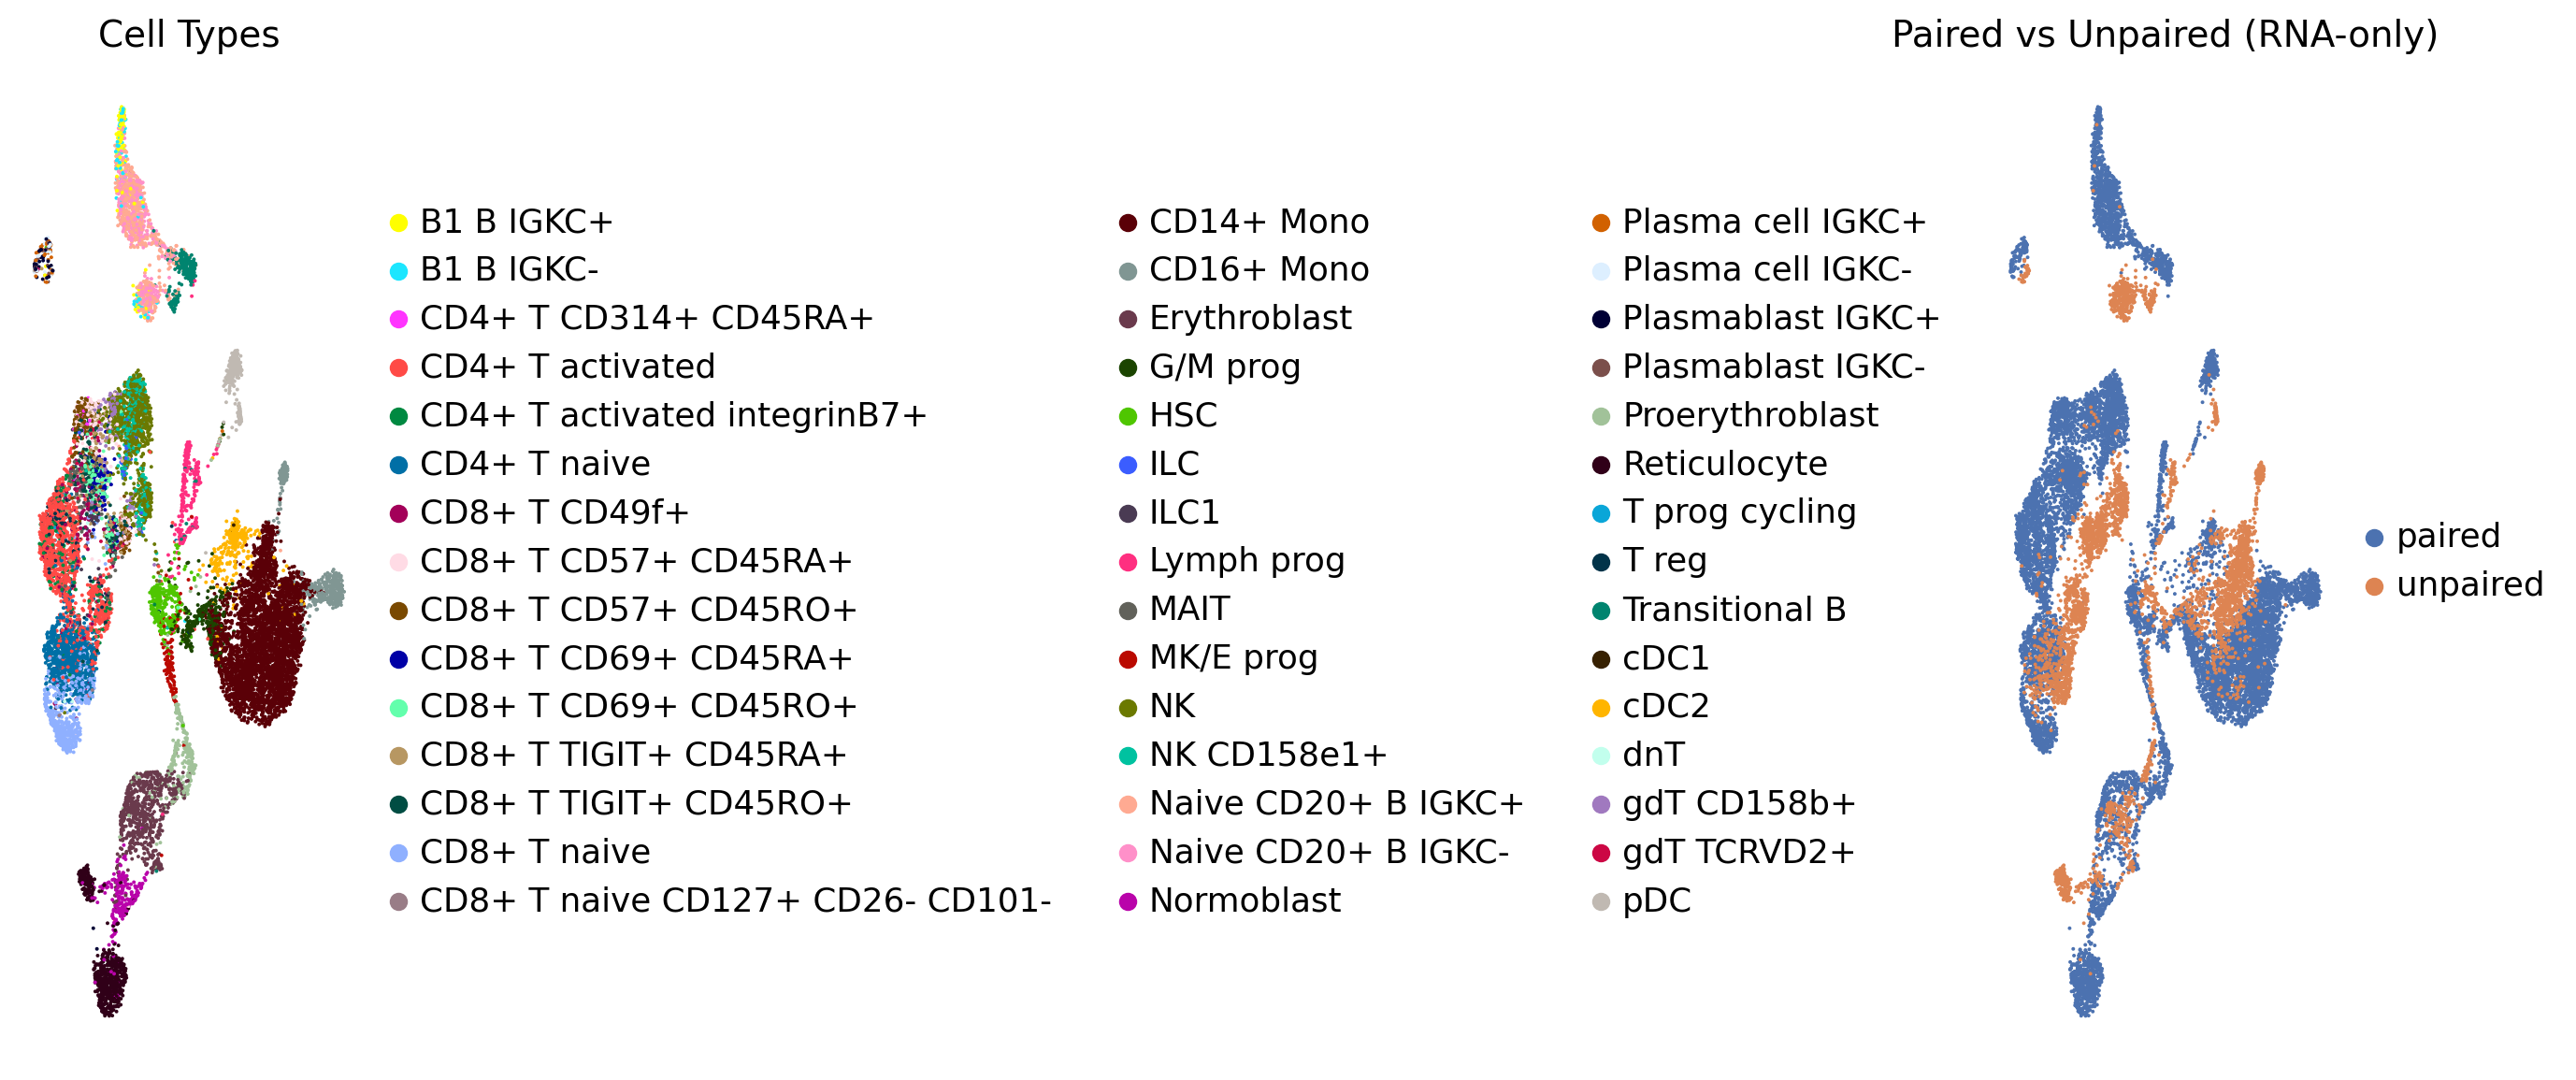

✅ Saved: figures/01_umap_paired_unpaired.png


In [12]:
# Build UMAP on full dataset latent space
sc.pp.neighbors(adata, use_rep='X_multigrate')
sc.tl.umap(adata)

os.makedirs("figures", exist_ok=True)

# Plot paired vs unpaired
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.umap(adata, color='cell_type', frameon=False,
           title='Cell Types', ax=axes[0], show=False)
sc.pl.umap(adata, color='paired', frameon=False,
           title='Paired vs Unpaired (RNA-only)', ax=axes[1], show=False,
           palette={'paired': '#4C72B0', 'unpaired': '#DD8452'})
plt.tight_layout()
plt.savefig("figures/01_umap_paired_unpaired.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/01_umap_paired_unpaired.png")


## Step 10 — Evaluate imputation accuracy

We compute Pearson correlation between imputed and true protein values
for each protein separately, then show the mean across all proteins.
Higher correlation = better imputation.


In [19]:
import torch

# Check what the decoder actually outputs
dl = model._make_data_loader(adata=adata_unpaired_subset, batch_size=4)
batch = next(iter(dl))

with torch.no_grad():
    inf = model.module.inference(**model.module._get_inference_input(batch))
    gen = model.module.generative(**model.module._get_generative_input(batch, inf))

print("Generative output keys:", list(gen.keys()))
print()
for k, v in gen.items():
    if hasattr(v, 'shape'):
        print(f"  {k}: shape {v.shape}")
    else:
        print(f"  {k}: {type(v)}")

Generative output keys: ['rs']

  rs: <class 'list'>


In [20]:
print("Length of rs:", len(gen['rs']))
for i, item in enumerate(gen['rs']):
    if hasattr(item, 'shape'):
        print(f"  rs[{i}]: shape {item.shape}")
    elif hasattr(item, '__len__'):
        print(f"  rs[{i}]: type {type(item)}, len {len(item)}")
        if hasattr(item[0], 'shape'):
            print(f"    rs[{i}][0]: shape {item[0].shape}")
    else:
        print(f"  rs[{i}]: {type(item)}")

Length of rs: 2
  rs[0]: shape torch.Size([4, 4000])
  rs[1]: shape torch.Size([4, 134])


In [21]:
import torch
from scipy.stats import pearsonr

# Extract imputed protein values using decoder output rs[1]
@torch.no_grad()
def get_imputed_proteins(model, adata_subset):
    dl = model._make_data_loader(adata=adata_subset, batch_size=256)
    all_prot = []
    for batch in dl:
        inf = model.module.inference(**model.module._get_inference_input(batch))
        gen = model.module.generative(**model.module._get_generative_input(batch, inf))
        all_prot.append(gen['rs'][1].cpu().numpy())
    return np.vstack(all_prot)

imputed_proteins = get_imputed_proteins(model, adata_unpaired_subset)
print(f"Imputed proteins shape: {imputed_proteins.shape}")

# Ground truth
ground_truth_clean = np.nan_to_num(ground_truth, nan=0.0)
imputed_clean = np.nan_to_num(imputed_proteins, nan=0.0)

# Pearson r per protein
protein_names = list(adt.var_names)
pearson_rs = []

for i, prot in enumerate(protein_names):
    gt_col = ground_truth_clean[:, i]
    imp_col = imputed_clean[:, i]
    if np.std(gt_col) < 1e-10 or np.std(imp_col) < 1e-10:
        pearson_rs.append(0.0)
    else:
        r, _ = pearsonr(gt_col, imp_col)
        pearson_rs.append(r if not np.isnan(r) else 0.0)

print(f"Mean Pearson r: {np.mean(pearson_rs):.4f}")
print("\nTop 10 proteins:")
top10 = sorted(zip(protein_names, pearson_rs), key=lambda x: x[1], reverse=True)[:10]
for prot, r in top10:
    print(f"  {prot:15s}: {r:.4f}")

Imputed proteins shape: (3750, 134)
Mean Pearson r: 0.7240

Top 10 proteins:
  CD71           : 0.9516
  CD45           : 0.9415
  CD36           : 0.9411
  CD5            : 0.9409
  CD3            : 0.9362
  CD2            : 0.9356
  CD72           : 0.9258
  CD33           : 0.9253
  CD11a          : 0.9245
  CD7            : 0.9235


## Step 11 — Plot Pearson correlation barplot (Figure 4b equivalent)

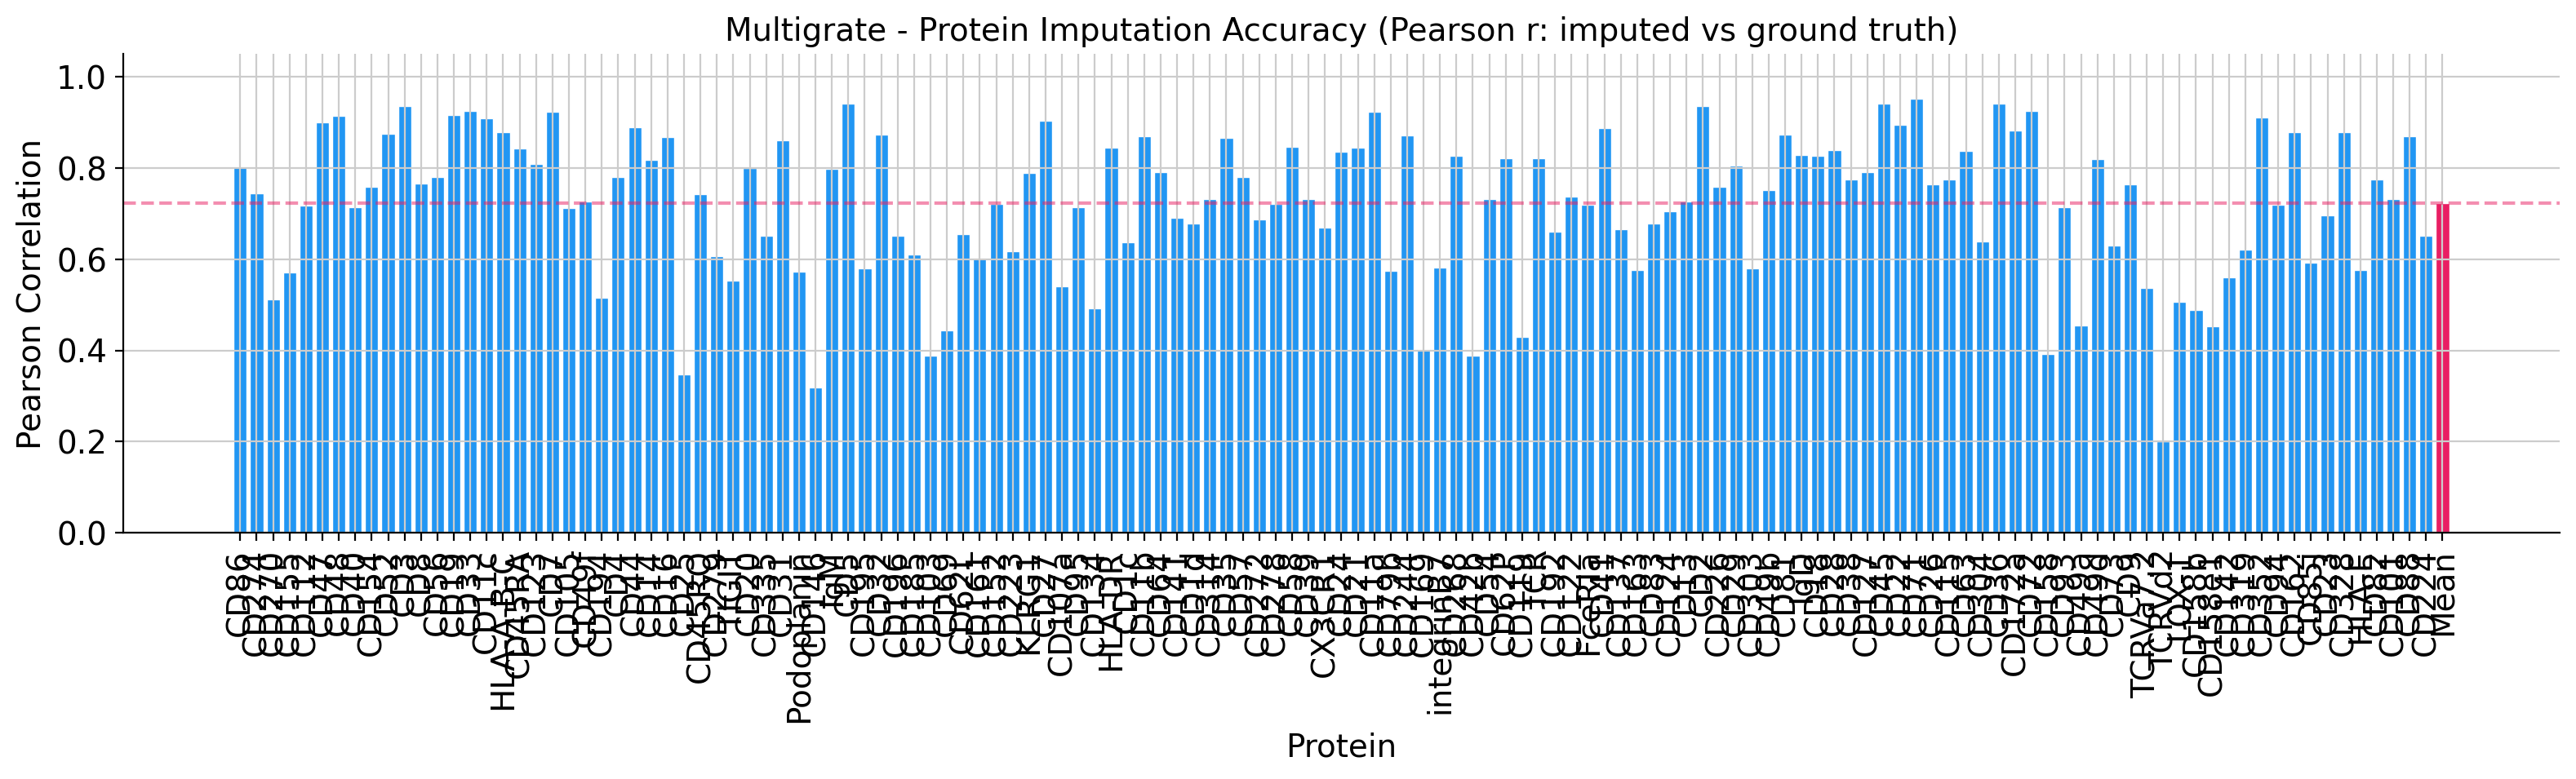

Saved: figures/02_pearson_barplot.png
Mean Pearson r: 0.7240


In [25]:
fig, ax = plt.subplots(figsize=(16, 5))

colors = ['#2196F3'] * len(protein_names) + ['#E91E63']
all_names  = protein_names + ['Mean']
all_values = pearson_rs + [float(np.mean(pearson_rs))]

bars = ax.bar(all_names, all_values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Protein')
ax.set_title('Multigrate - Protein Imputation Accuracy (Pearson r: imputed vs ground truth)')
ax.set_ylim(0, 1.05)
ax.axhline(y=float(np.mean(pearson_rs)), color='#E91E63', linestyle='--', alpha=0.5, linewidth=1.5)
ax.tick_params(axis='x', rotation=90)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("figures/02_pearson_barplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/02_pearson_barplot.png")
print(+f"Mean Pearson r: {np.mean(pearson_rs):.4f}")

## Step 12 — Training loss curve

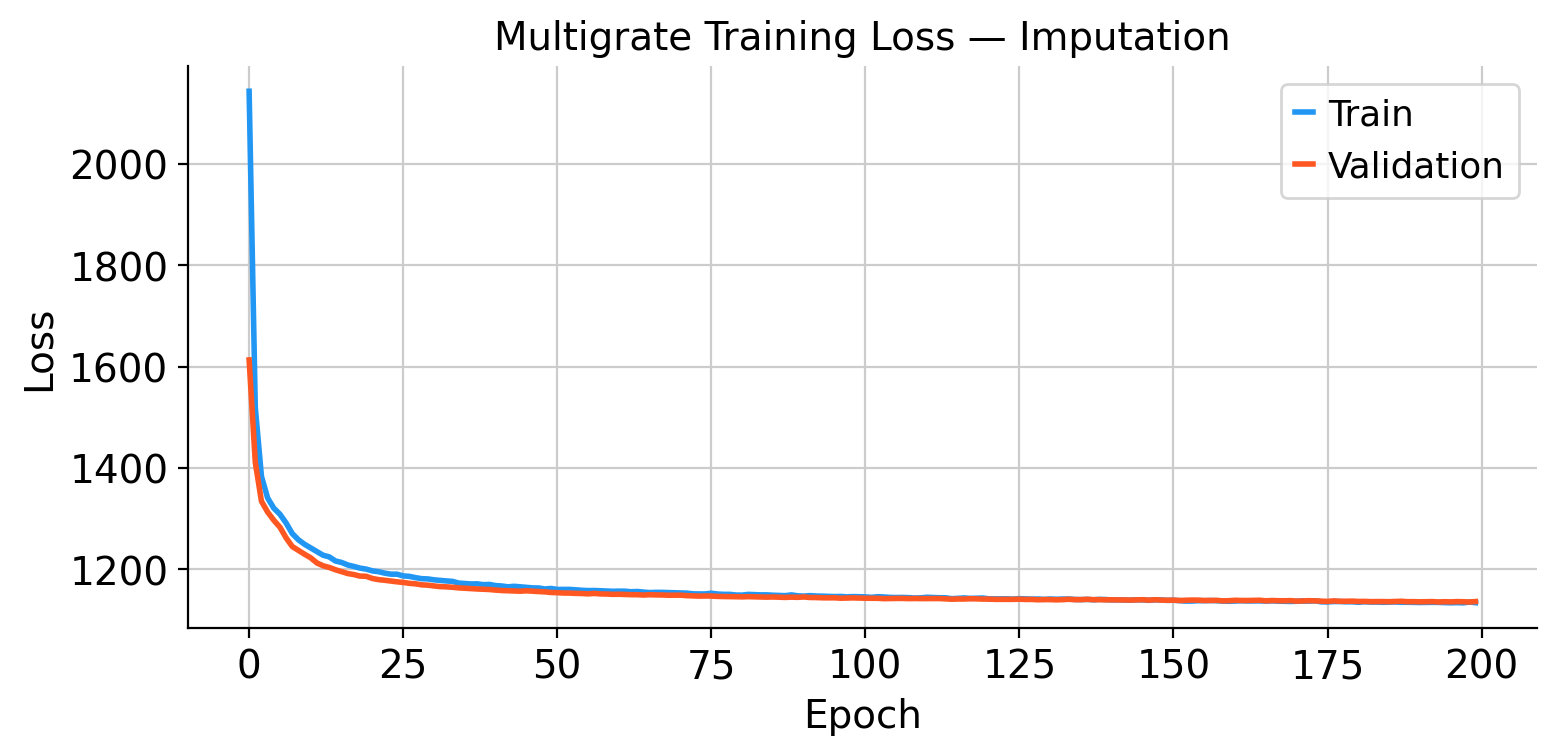

✅ Saved: figures/03_training_loss.png


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.history['train_loss'], color='#2196F3', linewidth=2, label='Train')
ax.plot(model.history['validation_loss'], color='#FF5722', linewidth=2, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Multigrate Training Loss — Imputation')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/03_training_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/03_training_loss.png")


## Step 13 — Download figures

In [24]:
figs = sorted(os.listdir("figures"))
print("Figures ready to download:")
for f in figs:
    size = os.path.getsize(f"figures/{f}") // 1024
    print(f"  📊 figures/{f}  ({size} KB)")

print()
print("Download via: 📁 folder icon (left sidebar) → figures/ → right-click → Download")
print("Then place in: multigrate-multiomics/02_protein_imputation/figures/")
print("Then push:")
print("  git add .")
print("  git commit -m 'Add Experiment 2: protein imputation'")
print("  git push")


Figures ready to download:
  📊 figures/01_umap_paired_unpaired.png  (390 KB)
  📊 figures/02_pearson_barplot.png  (153 KB)
  📊 figures/03_training_loss.png  (48 KB)

Download via: 📁 folder icon (left sidebar) → figures/ → right-click → Download
Then place in: multigrate-multiomics/02_protein_imputation/figures/
Then push:
  git add .
  git commit -m 'Add Experiment 2: protein imputation'
  git push


---
## ✅ Summary

| Step | What happened |
|------|--------------|
| 1 | Installed multigrate from GitHub source |
| 2 | Imported libraries |
| 3 | Downloaded NeurIPS 2021 CITE-seq dataset |
| 4 | Preprocessed RNA and ADT |
| 5 | Split 75% paired / 25% RNA-only |
| 6 | Combined modalities, set up MultiVAE |
| 7 | Trained 200 epochs |
| 8 | Extracted latent space |
| 9 | UMAP coloured by cell type and paired/unpaired |
| 10 | Computed Pearson r per protein |
| 11 | Barplot of imputation accuracy |
| 12 | Training loss curve |

**Next:** Open `03_query_to_reference/query_mapping.ipynb`

---
*Based on: https://github.com/theislab/multigrate_reproducibility*
